# Graficos sumo

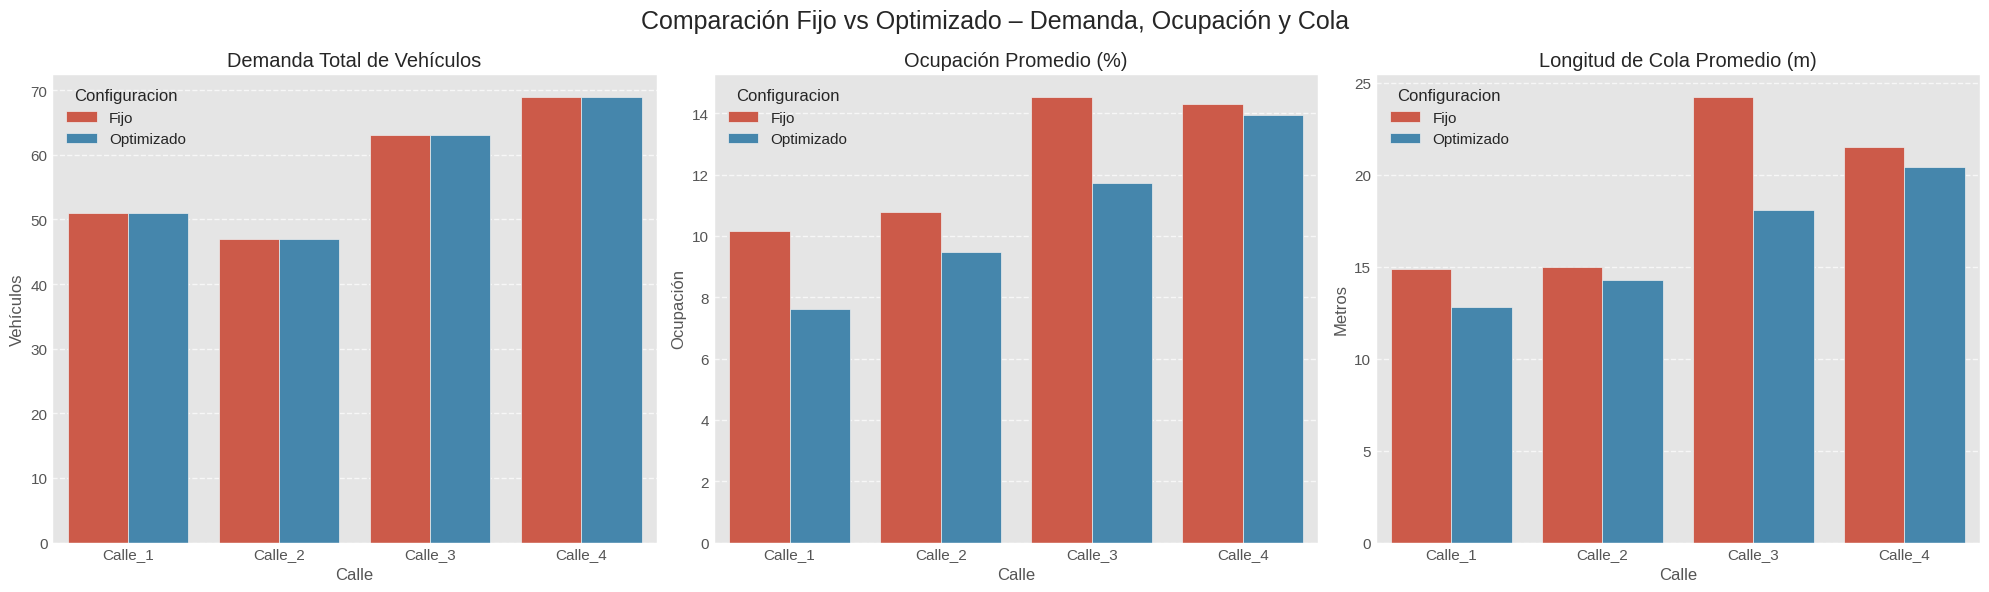

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")


calles_base = {
    "Calle_1": ["calles_sumo/ocupacion11.xml", "calles_sumo/ocupacion12.xml"],
    "Calle_2": ["calles_sumo/ocupacion21.xml", "calles_sumo/ocupacion22.xml"],
    "Calle_3": ["calles_sumo/ocupacion31.xml", "calles_sumo/ocupacion32.xml"],
    "Calle_4": ["calles_sumo/ocupacion41.xml", "calles_sumo/ocupacion42.xml"],
}

calles_opt = {
    "Calle_1": ["calles_sumo_opt/ocupacion11.xml", "calles_sumo_opt/ocupacion12.xml"],
    "Calle_2": ["calles_sumo_opt/ocupacion21.xml", "calles_sumo_opt/ocupacion22.xml"],
    "Calle_3": ["calles_sumo_opt/ocupacion31.xml", "calles_sumo_opt/ocupacion32.xml"],
    "Calle_4": ["calles_sumo_opt/ocupacion41.xml", "calles_sumo_opt/ocupacion42.xml"],
}


def cargar_detector(path):
    return pd.read_xml(path, parser="etree")

def consolidar(config, etiqueta):
    data = []
    for calle, archivos in config.items():
        dfs = [cargar_detector(a) for a in archivos]
        df = pd.concat(dfs, ignore_index=True)

        df["Calle"] = calle
        df["Configuracion"] = etiqueta

        data.append(df)

    return pd.concat(data, ignore_index=True)


df_fijo = consolidar(calles_base, "Fijo")
df_opt  = consolidar(calles_opt, "Optimizado")

df_total = pd.concat([df_fijo, df_opt], ignore_index=True)


resumen = df_total.groupby(
    ["Configuracion", "Calle"]
).agg(
    Demanda_Total=("nVehEntered", "sum"),
    Cola_Promedio=("maxJamLengthInMeters", "mean"),
    Ocupacion_Promedio=("meanOccupancy", "mean"),
).reset_index()


fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Comparación Fijo vs Optimizado – Demanda, Ocupación y Cola", fontsize=18)

sns.barplot(
    data=resumen,
    x="Calle",
    y="Demanda_Total",
    hue="Configuracion",
    ax=axes[0]
)
axes[0].set_title("Demanda Total de Vehículos")
axes[0].set_ylabel("Vehículos")

sns.barplot(
    data=resumen,
    x="Calle",
    y="Ocupacion_Promedio",
    hue="Configuracion",
    ax=axes[1]
)
axes[1].set_title("Ocupación Promedio (%)")
axes[1].set_ylabel("Ocupación")

sns.barplot(
    data=resumen,
    x="Calle",
    y="Cola_Promedio",
    hue="Configuracion",
    ax=axes[2]
)
axes[2].set_title("Longitud de Cola Promedio (m)")
axes[2].set_ylabel("Metros")

for ax in axes:
    ax.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()
